In [3]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv

In [4]:
load_dotenv()

True

In [5]:
class AgentState(TypedDict):
    messages: List[HumanMessage]

In [10]:
llm = ChatOpenAI(model="qwen-plus")

In [11]:
def process(state: AgentState) -> AgentState:
    response = llm.invoke(state["messages"])
    print(f'\n{response}')
    return state

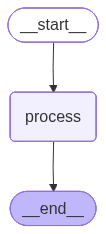

In [14]:
graph = StateGraph(AgentState)
graph.add_node("process", process)
graph.set_entry_point("process")
graph.set_finish_point("process")
graph.compile()

In [15]:
app = graph.compile()

In [13]:
app.invoke({"messages": "你好啊"})


content='你好呀！😊 很高兴见到你～  \n有什么想聊的、需要帮忙的，或者只是想轻松说说话，我都很乐意陪你！✨  \n（比如：解答问题、写文字、学知识、一起头脑风暴，甚至讲个冷笑话也行～）  \n随时告诉我吧！ 🌟' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 10, 'total_tokens': 77, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'qwen-plus', 'system_fingerprint': None, 'id': 'chatcmpl-bb7f34d6-61c4-9bbf-820f-f5376aeb78c2', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019d55bb-9415-7032-91eb-06cd243efb3c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 10, 'output_tokens': 67, 'total_tokens': 77, 'input_token_details': {'cache_read': 0}, 'output_token_details': {}}


{'messages': '你好啊'}